# Bank Churners — Modeling (`02_modeling`)

**Objective:** Train and compare churn classifiers with reproducible preprocessing, Optuna tuning, and explicit final model/threshold decisions.

**Assumptions:** Patterns are predictive, not causal. Leakage columns from EDA remain excluded. Validation drives selection; test is evaluated once on the final choice.

### Notebook map (per `docs/05_task_modeling.md`)
1. Setup and paths
2. Load data and target
3. Stratified 70 / 15 / 15 split
4. Preprocessing pipeline
5. Baseline — Logistic Regression
6. Random Forest
7. XGBoost
8. LightGBM
9. Model comparison (tables)
10. Visual metric comparison
11. Final model selection
12. Threshold selection (recall ≥ 0.6 on validation)
13. Feature importance (final model)
14. Inference contract
15. Save artifact and predictions
16. Limitations


In [1]:
# =============================================================================
# 0. Setup
# =============================================================================
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from IPython.display import display
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "BankChurners.csv").exists():
    ROOT = Path.cwd().parent
if not (ROOT / "data" / "raw" / "BankChurners.csv").exists():
    raise FileNotFoundError("Place BankChurners.csv in data/raw/")

RAW_PATH = ROOT / "data" / "raw" / "BankChurners.csv"
FIG_DIR = ROOT / "reports" / "figures"
TABLE_DIR = ROOT / "reports" / "tables"
MODEL_DIR = ROOT / "artifacts" / "models"
PRED_DIR = ROOT / "artifacts" / "predictions"
LOG_DIR = ROOT / "artifacts" / "logs"

for d in (FIG_DIR, TABLE_DIR, MODEL_DIR, PRED_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)

LEAKAGE_COLS = ['CLIENTNUM', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

NUMERIC_FEATURES = ['Customer_Age', 'Dependent_count', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

CATEGORICAL_FEATURES = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

ORDINAL_FEATURES = ['Education_Level', 'Income_Category']

NOMINAL_FEATURES = ['Gender', 'Marital_Status', 'Card_Category']

EDUCATION_ORDER = ['Unknown', 'Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate']

INCOME_ORDER = ['Unknown', 'Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']

TARGET_COL = "is_churn"
N_OPTUNA_TRIALS = 25

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150})


C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data loading

Load the raw CSV, define the binary churn target, and keep only modeling features (leakage columns dropped).


In [2]:
df_raw = pd.read_csv(RAW_PATH)
print("Raw shape:", df_raw.shape)

df = df_raw.drop(columns=[c for c in LEAKAGE_COLS if c in df_raw.columns], errors="ignore")
df[TARGET_COL] = (df["Attrition_Flag"] == "Attrited Customer").astype(int)

missing_feats = [c for c in FEATURE_COLUMNS if c not in df.columns]
if missing_feats:
    raise ValueError(f"Missing feature columns: {missing_feats}")

X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COL].copy()

print("Churn rate:", round(y.mean(), 4))
print("Feature matrix:", X.shape)
X.head()


Raw shape: (10127, 23)
Churn rate: 0.1607
Feature matrix: (10127, 19)


,Customer_Age,Dependent_count,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Trans_Amt,Total_Trans_Ct,Total_Amt_Chng_Q4_Q1,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender,Education_Level,Marital_Status,Income_Category,Card_Category
0,45,3,12691.0,777,11914.0,39,5,1,3,1144,42,1.335,1.625,0.061,M,High School,Married,$60K - $80K,Blue
1,49,5,8256.0,864,7392.0,44,6,1,2,1291,33,1.541,3.714,0.105,F,Graduate,Single,Less than $40K,Blue
2,51,3,3418.0,0,3418.0,36,4,1,0,1887,20,2.594,2.333,0.000,M,Graduate,Married,$80K - $120K,Blue
3,40,4,3313.0,2517,796.0,34,3,4,1,1171,20,1.405,2.333,0.760,F,High School,Unknown,Less than $40K,Blue
4,40,3,4716.0,0,4716.0,21,5,1,0,816,28,2.175,2.500,0.000,M,Uneducated,Married,$60K - $80K,Blue


## 2. Train / validation / test split

Fixed **70% / 15% / 15%** split with **stratification** on the churn label (`random_state=42`).

- **Train:** fit preprocessing and models
- **Validation:** Optuna tuning, model selection, threshold selection
- **Test:** holdout evaluation only (no tuning or selection)


In [3]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_holdout,
    y_holdout,
    test_size=0.50,
    stratify=y_holdout,
    random_state=RANDOM_SEED,
)

splits = {
    "train": (X_train, y_train),
    "validation": (X_val, y_val),
    "test": (X_test, y_test),
}

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(y_train), len(y_val), len(y_test)],
        "churn_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
        "pct_of_total": [
            len(y_train) / len(y),
            len(y_val) / len(y),
            len(y_test) / len(y),
        ],
    }
)
split_summary.to_csv(TABLE_DIR / "modeling_split_summary.csv", index=False)
display(split_summary)


,split,rows,churn_rate,pct_of_total
0,train,7088,0.160694,0.699911
1,validation,1519,0.160632,0.149995
2,test,1520,0.160526,0.150094


## 3. Preprocessing

Reproducible `ColumnTransformer` aligned with EDA (`01_eda.ipynb`):

| Block | Columns | Transformer |
|-------|---------|-------------|
| Numeric | 14 usage/demographic numerics | `StandardScaler` |
| Ordinal | `Education_Level`, `Income_Category` | `OrdinalEncoder` with **fixed** category order |
| Nominal | `Gender`, `Marital_Status`, `Card_Category` | `OneHotEncoder(drop='first')` |

The unfitted preprocessor is cloned inside each Optuna trial so tuning does not reuse fitted state across trials.


In [4]:
ordinal_categories = [EDUCATION_ORDER, INCOME_ORDER]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        (
            "ord",
            OrdinalEncoder(
                categories=ordinal_categories,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            ORDINAL_FEATURES,
        ),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            NOMINAL_FEATURES,
        ),
    ],
    remainder="drop",
)

# Fit once on train for inspection; modeling pipelines clone this unfitted object.
_prep_fit = clone(preprocessor)
_prep_fit.fit(X_train)
print("Transformed feature count:", _prep_fit.transform(X_train).shape[1])


Transformed feature count: 23


## 4. Evaluation helpers

Metrics are reported for the **positive churn class** (`1`). `evaluate_model` iterates `for name, (X_split, y_split) in splits.items()` as required.


In [5]:
def evaluate_model(estimator, splits, threshold=0.5):
    """Return a long-form metrics DataFrame for train / validation / test."""
    rows = []
    for name, (X_split, y_split) in splits.items():
        proba = estimator.predict_proba(X_split)[:, 1]
        pred = (proba >= threshold).astype(int)
        rows.append(
            {
                "split": name,
                "roc_auc": roc_auc_score(y_split, proba),
                "precision": precision_score(y_split, pred, zero_division=0),
                "recall": recall_score(y_split, pred, zero_division=0),
                "f1": f1_score(y_split, pred, zero_division=0),
                "accuracy": accuracy_score(y_split, pred),
                "threshold": threshold,
            }
        )
    return pd.DataFrame(rows)


def get_transformed_feature_names(prep):
    names = []
    names.extend(NUMERIC_FEATURES)
    for col in ORDINAL_FEATURES:
        names.append(col)
    cat_encoder = prep.named_transformers_["cat"]
    names.extend(list(cat_encoder.get_feature_names_out(NOMINAL_FEATURES)))
    return names


optuna_rows = []
tuned_pipelines = {}
metrics_frames = []


## 5. Baseline — Logistic Regression

Tune **3–5** hyperparameters with Optuna (`n_trials=25`), optimizing **validation ROC-AUC**. Each trial clones the preprocessor to avoid leakage across fits.


In [6]:
from sklearn.linear_model import LogisticRegression

def default_logistic():
    return LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced')

def suggest_logistic(trial):

    return {
        "C": trial.suggest_float("C", 1e-3, 10.0, log=True),
        "penalty": trial.suggest_categorical("penalty", ["l2"]),
        "solver": trial.suggest_categorical("solver", ["lbfgs", "saga"]),
    }


def tune_logistic(X_train, y_train, X_val, y_val, preprocessor, n_trials=25):
    def objective(trial):
        params = suggest_logistic(trial)
        clf = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced')
        clf.set_params(**params)
        pipe = Pipeline([("prep", clone(preprocessor)), ("model", clf)])
        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, proba)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study

# Default (pre-tuning) pipeline for comparison tables
pipe_logistic_default = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", default_logistic()),
])
pipe_logistic_default.fit(X_train, y_train)

study_logistic = tune_logistic(X_train, y_train, X_val, y_val, preprocessor)
best_params_logistic = study_logistic.best_params
best_val_auc_logistic = study_logistic.best_value

pipe_logistic = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", default_logistic()),
])
pipe_logistic.named_steps["model"].set_params(**best_params_logistic)
pipe_logistic.fit(X_train, y_train)

optuna_rows.append({
    "model": "logistic",
    "best_validation_roc_auc": best_val_auc_logistic,
    "best_params": json.dumps(best_params_logistic),
    "n_trials": 25,
    "metric": "roc_auc",
    "default_params": {"C": 1.0, "penalty": "l2", "solver": "lbfgs", "class_weight": "balanced"},
})

tuned_pipelines["logistic"] = pipe_logistic
print(f"5. Baseline — Logistic Regression: best validation ROC-AUC = {best_val_auc_logistic:.4f}")
print("Best params:", best_params_logistic)


5. Baseline — Logistic Regression: best validation ROC-AUC = 0.9158
Best params: {'C': 0.44455345039994676, 'penalty': 'l2', 'solver': 'saga'}


## 6. Random Forest

Tune **3–5** hyperparameters with Optuna (`n_trials=25`), optimizing **validation ROC-AUC**. Each trial clones the preprocessor to avoid leakage across fits.


In [7]:
from sklearn.ensemble import RandomForestClassifier

def default_random_forest():
    return RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced', n_jobs=-1)

def suggest_random_forest(trial):

    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400, step=50),
        "max_depth": trial.suggest_int("max_depth", 4, 16),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
    }


def tune_random_forest(X_train, y_train, X_val, y_val, preprocessor, n_trials=25):
    def objective(trial):
        params = suggest_random_forest(trial)
        clf = RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced', n_jobs=-1)
        clf.set_params(**params)
        pipe = Pipeline([("prep", clone(preprocessor)), ("model", clf)])
        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, proba)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study

# Default (pre-tuning) pipeline for comparison tables
pipe_random_forest_default = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", default_random_forest()),
])
pipe_random_forest_default.fit(X_train, y_train)

study_random_forest = tune_random_forest(X_train, y_train, X_val, y_val, preprocessor)
best_params_random_forest = study_random_forest.best_params
best_val_auc_random_forest = study_random_forest.best_value

pipe_random_forest = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", default_random_forest()),
])
pipe_random_forest.named_steps["model"].set_params(**best_params_random_forest)
pipe_random_forest.fit(X_train, y_train)

optuna_rows.append({
    "model": "random_forest",
    "best_validation_roc_auc": best_val_auc_random_forest,
    "best_params": json.dumps(best_params_random_forest),
    "n_trials": 25,
    "metric": "roc_auc",
    "default_params": {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
})

tuned_pipelines["random_forest"] = pipe_random_forest
print(f"6. Random Forest: best validation ROC-AUC = {best_val_auc_random_forest:.4f}")
print("Best params:", best_params_random_forest)


6. Random Forest: best validation ROC-AUC = 0.9868
Best params: {'n_estimators': 250, 'max_depth': 14, 'min_samples_leaf': 2, 'max_features': 'sqrt'}


## 7. XGBoost

Tune **3–5** hyperparameters with Optuna (`n_trials=25`), optimizing **validation ROC-AUC**. Each trial clones the preprocessor to avoid leakage across fits.


In [8]:
from xgboost import XGBClassifier

def default_xgboost():
    return XGBClassifier(objective='binary:logistic', eval_metric='auc', random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)

def suggest_xgboost(trial):

    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }


def tune_xgboost(X_train, y_train, X_val, y_val, preprocessor, n_trials=25):
    def objective(trial):
        params = suggest_xgboost(trial)
        clf = XGBClassifier(objective='binary:logistic', eval_metric='auc', random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)
        clf.set_params(**params)
        pipe = Pipeline([("prep", clone(preprocessor)), ("model", clf)])
        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, proba)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study

# Default (pre-tuning) pipeline for comparison tables
pipe_xgboost_default = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", default_xgboost()),
])
pipe_xgboost_default.fit(X_train, y_train)

study_xgboost = tune_xgboost(X_train, y_train, X_val, y_val, preprocessor)
best_params_xgboost = study_xgboost.best_params
best_val_auc_xgboost = study_xgboost.best_value

pipe_xgboost = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", default_xgboost()),
])
pipe_xgboost.named_steps["model"].set_params(**best_params_xgboost)
pipe_xgboost.fit(X_train, y_train)

optuna_rows.append({
    "model": "xgboost",
    "best_validation_roc_auc": best_val_auc_xgboost,
    "best_params": json.dumps(best_params_xgboost),
    "n_trials": 25,
    "metric": "roc_auc",
    "default_params": {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1},
})

tuned_pipelines["xgboost"] = pipe_xgboost
print(f"7. XGBoost: best validation ROC-AUC = {best_val_auc_xgboost:.4f}")
print("Best params:", best_params_xgboost)


7. XGBoost: best validation ROC-AUC = 0.9947
Best params: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.07723827453981533, 'subsample': 0.7067964291781478, 'colsample_bytree': 0.742502089555488}


## 8. LightGBM

Tune **3–5** hyperparameters with Optuna (`n_trials=25`), optimizing **validation ROC-AUC**. Each trial clones the preprocessor to avoid leakage across fits.


In [9]:
from lightgbm import LGBMClassifier

def default_lightgbm():
    return LGBMClassifier(objective='binary', random_state=RANDOM_SEED, verbosity=-1, n_jobs=-1)

def suggest_lightgbm(trial):

    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400, step=50),
        "num_leaves": trial.suggest_int("num_leaves", 16, 64),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    }


def tune_lightgbm(X_train, y_train, X_val, y_val, preprocessor, n_trials=25):
    def objective(trial):
        params = suggest_lightgbm(trial)
        clf = LGBMClassifier(objective='binary', random_state=RANDOM_SEED, verbosity=-1, n_jobs=-1)
        clf.set_params(**params)
        pipe = Pipeline([("prep", clone(preprocessor)), ("model", clf)])
        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, proba)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study

# Default (pre-tuning) pipeline for comparison tables
pipe_lightgbm_default = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", default_lightgbm()),
])
pipe_lightgbm_default.fit(X_train, y_train)

study_lightgbm = tune_lightgbm(X_train, y_train, X_val, y_val, preprocessor)
best_params_lightgbm = study_lightgbm.best_params
best_val_auc_lightgbm = study_lightgbm.best_value

pipe_lightgbm = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", default_lightgbm()),
])
pipe_lightgbm.named_steps["model"].set_params(**best_params_lightgbm)
pipe_lightgbm.fit(X_train, y_train)

optuna_rows.append({
    "model": "lightgbm",
    "best_validation_roc_auc": best_val_auc_lightgbm,
    "best_params": json.dumps(best_params_lightgbm),
    "n_trials": 25,
    "metric": "roc_auc",
    "default_params": {"n_estimators": 200, "num_leaves": 31, "learning_rate": 0.1},
})

tuned_pipelines["lightgbm"] = pipe_lightgbm
print(f"8. LightGBM: best validation ROC-AUC = {best_val_auc_lightgbm:.4f}")
print("Best params:", best_params_lightgbm)


8. LightGBM: best validation ROC-AUC = 0.9949
Best params: {'n_estimators': 200, 'num_leaves': 54, 'learning_rate': 0.06107649590096613, 'min_child_samples': 35, 'subsample': 0.9238315673412457}


## 9. Model comparison (tables)

Compare **Logistic Regression**, **Random Forest**, **XGBoost**, and **LightGBM** on train, validation, and test at threshold 0.5 before final threshold tuning.


In [10]:
model_order = ["logistic", "random_forest", "xgboost", "lightgbm"]
for key in model_order:
    pipe = tuned_pipelines[key]
    m = evaluate_model(pipe, splits, threshold=0.5)
    m["model"] = key
    metrics_frames.append(m)

metrics_all = pd.concat(metrics_frames, ignore_index=True)
col_order = ["model", "split", "roc_auc", "precision", "recall", "f1", "accuracy", "threshold"]
metrics_all = metrics_all[col_order]
metrics_all.to_csv(TABLE_DIR / "modeling_all_models_metrics.csv", index=False)

optuna_df = pd.DataFrame(optuna_rows)
optuna_df.to_csv(TABLE_DIR / "modeling_optuna_summary.csv", index=False)

pivot_auc = metrics_all.pivot(index="model", columns="split", values="roc_auc")
display(pivot_auc.round(4))
metrics_all.head(12)


split,test,train,validation
model,,,
lightgbm,0.9916,1.0000,0.9949
logistic,0.9179,0.9308,0.9158
random_forest,0.9844,0.9998,0.9868
xgboost,0.9906,0.9992,0.9947


,model,split,roc_auc,precision,recall,f1,accuracy,threshold
0,logistic,train,0.930799,0.524784,0.855136,0.650417,0.852286,0.5
1,logistic,validation,0.915763,0.523438,0.823770,0.640127,0.851218,0.5
2,logistic,test,0.917885,0.510050,0.831967,0.632399,0.844737,0.5
3,random_forest,train,0.999816,0.971014,1.000000,0.985294,0.995203,0.5
4,random_forest,validation,0.986760,0.885463,0.823770,0.853503,0.954575,0.5
5,random_forest,test,0.984422,0.865801,0.819672,0.842105,0.950658,0.5
6,xgboost,train,0.999218,0.981283,0.966637,0.973905,0.991676,0.5
7,xgboost,validation,0.994654,0.934211,0.872951,0.902542,0.969717,0.5
8,xgboost,test,0.990563,0.938596,0.877049,0.906780,0.971053,0.5
9,lightgbm,train,1.000000,1.000000,1.000000,1.000000,1.000000,0.5


## 10. Visual metric comparison

Bar charts for validation metrics and grouped train/validation/test ROC-AUC to spot overfitting.


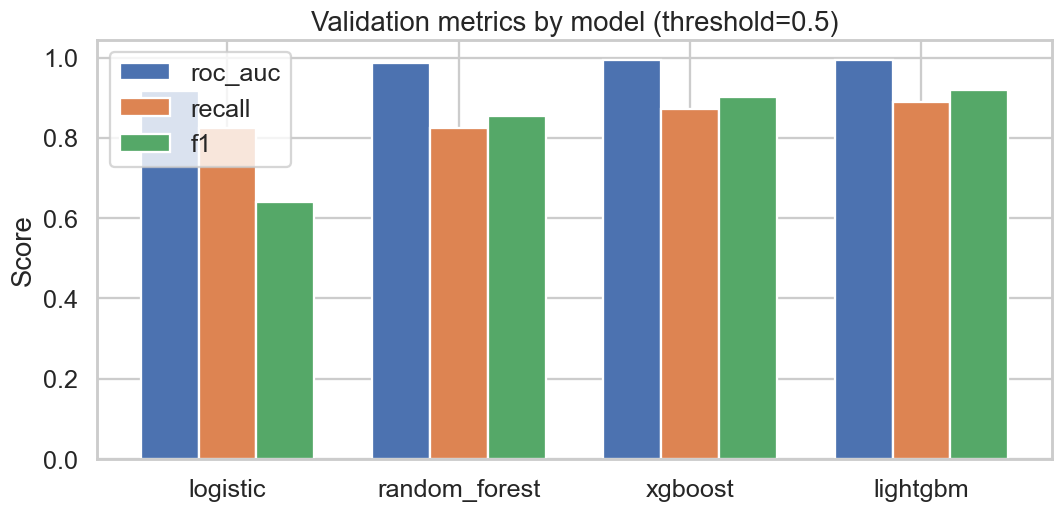

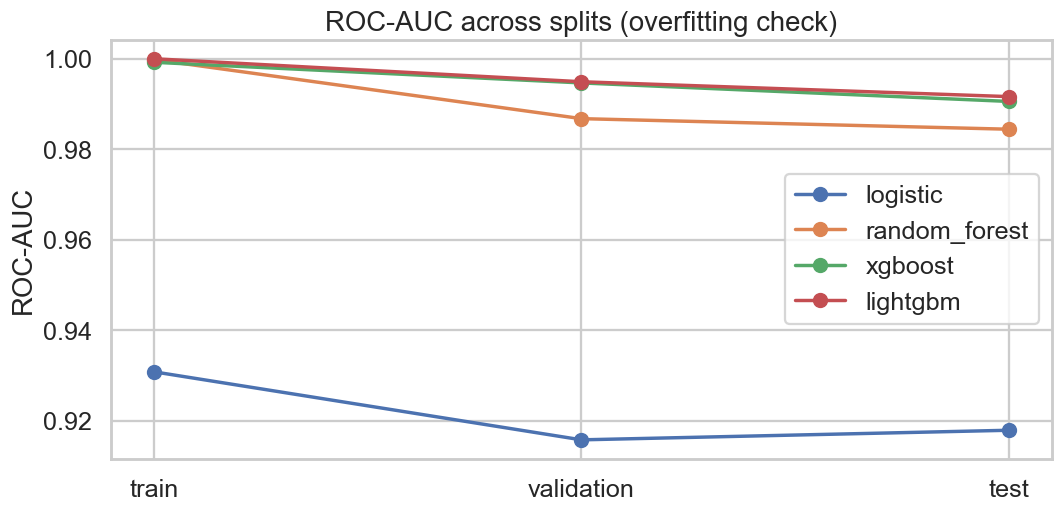

In [11]:
val_metrics = metrics_all[metrics_all["split"] == "validation"].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(model_order))
width = 0.25
for i, metric in enumerate(["roc_auc", "recall", "f1"]):
    ax.bar(x + i * width, val_metrics.set_index("model").loc[model_order, metric], width=width, label=metric)
ax.set_xticks(x + width)
ax.set_xticklabels(model_order)
ax.set_ylabel("Score")
ax.set_title("Validation metrics by model (threshold=0.5)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "modeling_validation_metrics_bar.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for key in model_order:
    sub = metrics_all[metrics_all["model"] == key]
    ax.plot(sub["split"], sub["roc_auc"], marker="o", label=key)
ax.set_ylabel("ROC-AUC")
ax.set_title("ROC-AUC across splits (overfitting check)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "modeling_roc_auc_by_split.png", bbox_inches="tight")
plt.show()


## 11. Final model selection

Primary ranking metric: **validation ROC-AUC**. The final model must **beat the logistic baseline** on validation. Test metrics are reported for transparency only.


In [12]:
val_auc = (
    metrics_all[metrics_all["split"] == "validation"]
    .set_index("model")["roc_auc"]
    .to_dict()
)
test_auc = (
    metrics_all[metrics_all["split"] == "test"]
    .set_index("model")["roc_auc"]
    .to_dict()
)

baseline_val_auc = val_auc["logistic"]
baseline_test_auc = test_auc["logistic"]

eligible = {
    k: v
    for k, v in val_auc.items()
    if v > baseline_val_auc
}
if not eligible:
    raise RuntimeError("No tuned model beat the baseline on validation ROC-AUC.")

final_model_name = max(eligible, key=eligible.get)
final_pipeline = tuned_pipelines[final_model_name]

selection_df = pd.DataFrame(
    [
        {
            "final_model": final_model_name,
            "validation_roc_auc": val_auc[final_model_name],
            "test_roc_auc": test_auc[final_model_name],
            "baseline_validation_roc_auc": baseline_val_auc,
            "baseline_test_roc_auc": baseline_test_auc,
            "beats_baseline_on_validation": val_auc[final_model_name] > baseline_val_auc,
            "beats_baseline_on_test": test_auc[final_model_name] > baseline_test_auc,
        }
    ]
)
selection_df.to_csv(TABLE_DIR / "modeling_final_selection.csv", index=False)
display(selection_df)


,final_model,validation_roc_auc,test_roc_auc,baseline_validation_roc_auc,baseline_test_roc_auc,beats_baseline_on_validation,beats_baseline_on_test
0,lightgbm,0.994915,0.99163,0.915763,0.917885,True,True


## 12. Threshold selection

Explore classification thresholds on **validation** probabilities. Choose the threshold that achieves **churn recall ≥ 0.6** and maximizes **F1** among feasible values (business trade-off: catch more churners while controlling false alarms).

False positives (predict churn, customer stays) waste retention budget; false negatives miss at-risk customers.


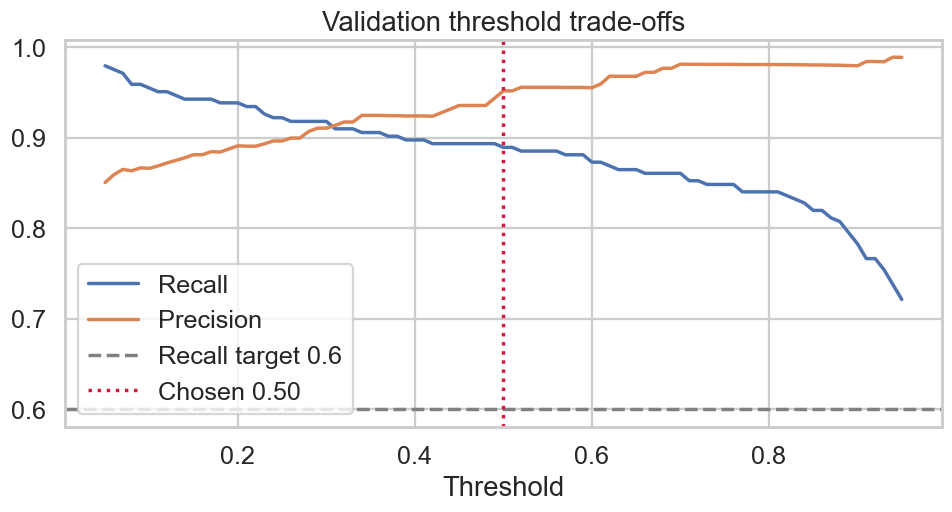

Chosen threshold: 0.5000
{'threshold': 0.5, 'precision': 0.9517543859649122, 'recall': 0.889344262295082, 'f1': 0.9194915254237288}


In [13]:
val_proba = final_pipeline.predict_proba(X_val)[:, 1]
threshold_grid = np.linspace(0.05, 0.95, 91)
thresh_rows = []
for t in threshold_grid:
    pred = (val_proba >= t).astype(int)
    thresh_rows.append(
        {
            "threshold": round(float(t), 4),
            "precision": precision_score(y_val, pred, zero_division=0),
            "recall": recall_score(y_val, pred, zero_division=0),
            "f1": f1_score(y_val, pred, zero_division=0),
        }
    )
threshold_df = pd.DataFrame(thresh_rows)
threshold_df.to_csv(TABLE_DIR / "modeling_threshold_grid.csv", index=False)

feasible = threshold_df[threshold_df["recall"] >= 0.6]
if feasible.empty:
    raise RuntimeError("No threshold on validation achieves recall >= 0.6.")

best_row = feasible.sort_values(["f1", "recall"], ascending=False).iloc[0]
chosen_threshold = float(best_row["threshold"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
ax.axhline(0.6, color="gray", linestyle="--", label="Recall target 0.6")
ax.axvline(chosen_threshold, color="crimson", linestyle=":", label=f"Chosen {chosen_threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_title("Validation threshold trade-offs")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "modeling_threshold_tradeoff.png", bbox_inches="tight")
plt.show()

print(f"Chosen threshold: {chosen_threshold:.4f}")
print(best_row.to_dict())


## 13. Feature importance (final model)

Drivers are **associations**, not proven causes. Importance is computed on transformed features from the fitted pipeline.


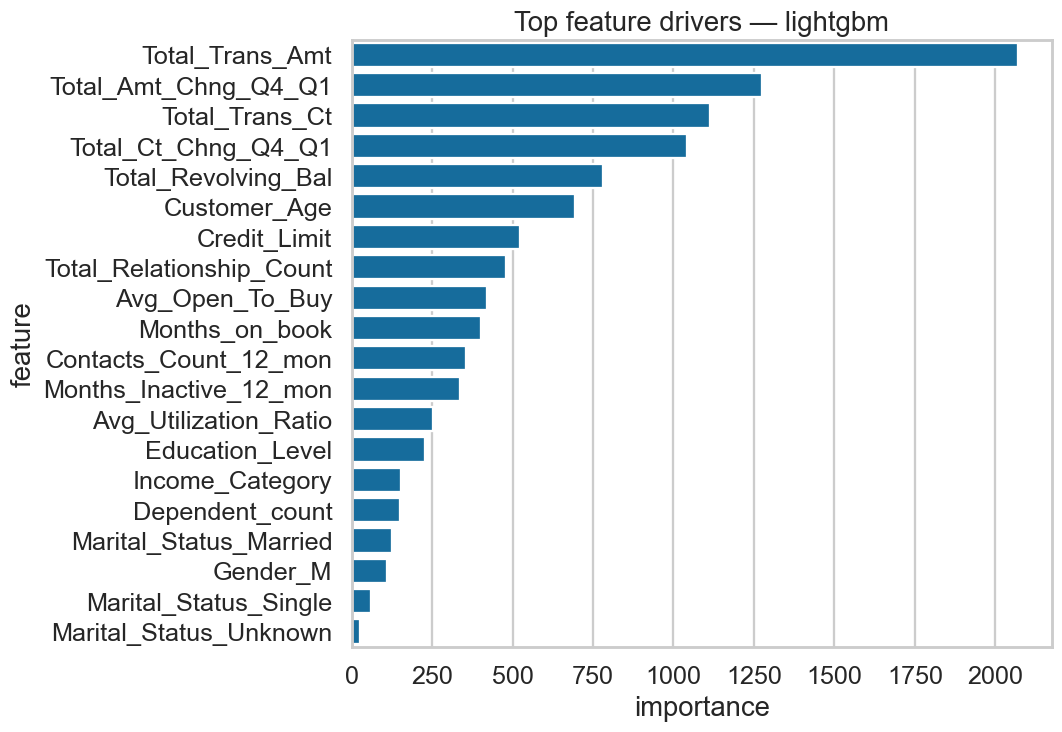

,feature,importance
9,Total_Trans_Amt,2071
11,Total_Amt_Chng_Q4_Q1,1274
10,Total_Trans_Ct,1112
12,Total_Ct_Chng_Q4_Q1,1041
3,Total_Revolving_Bal,780
0,Customer_Age,695
2,Credit_Limit,523
6,Total_Relationship_Count,479
4,Avg_Open_To_Buy,420
5,Months_on_book,403


In [14]:
prep_fitted = final_pipeline.named_steps["prep"]
clf_fitted = final_pipeline.named_steps["model"]
feature_names = get_transformed_feature_names(prep_fitted)

if hasattr(clf_fitted, "feature_importances_"):
    importances = clf_fitted.feature_importances_
elif hasattr(clf_fitted, "coef_"):
    importances = np.abs(clf_fitted.coef_).ravel()
else:
    raise ValueError("Final model does not expose importances or coefficients.")

imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)
imp_df.to_csv(TABLE_DIR / "modeling_final_feature_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=imp_df, y="feature", x="importance", ax=ax, color="#0072B2")
ax.set_title(f"Top feature drivers — {final_model_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "modeling_feature_importance.png", bbox_inches="tight")
plt.show()
imp_df


                ## 14. Inference contract

                The saved `churn_model_pipeline.joblib` artifact expects a pandas DataFrame with **19** columns (same names and semantics as training):

- `Customer_Age`
- `Dependent_count`
- `Credit_Limit`
- `Total_Revolving_Bal`
- `Avg_Open_To_Buy`
- `Months_on_book`
- `Total_Relationship_Count`
- `Months_Inactive_12_mon`
- `Contacts_Count_12_mon`
- `Total_Trans_Amt`
- `Total_Trans_Ct`
- `Total_Amt_Chng_Q4_Q1`
- `Total_Ct_Chng_Q4_Q1`
- `Avg_Utilization_Ratio`
- `Gender`
- `Education_Level`
- `Marital_Status`
- `Income_Category`
- `Card_Category`

Do **not** pass `CLIENTNUM`, `Attrition_Flag`, or either Naive Bayes classifier column. Categorical values must match training categories (including `Unknown` where applicable).


## 15. Save artifact and predictions

Persist a self-contained joblib bundle for the Streamlit app: fitted pipeline, decision threshold, and metadata.


,model,split,roc_auc,precision,recall,f1,accuracy,threshold
0,lightgbm,train,1.000000,1.000000,1.000000,1.000000,1.000000,0.5
1,lightgbm,validation,0.994915,0.951754,0.889344,0.919492,0.974984,0.5
2,lightgbm,test,0.991630,0.920705,0.856557,0.887473,0.965132,0.5


Saved model: C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\artifacts\models\churn_model_pipeline.joblib
Saved predictions: C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\artifacts\predictions\churn_predictions_train.csv
Saved predictions: C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\artifacts\predictions\churn_predictions_validation.csv
Saved predictions: C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\artifacts\predictions\churn_predictions_test.csv


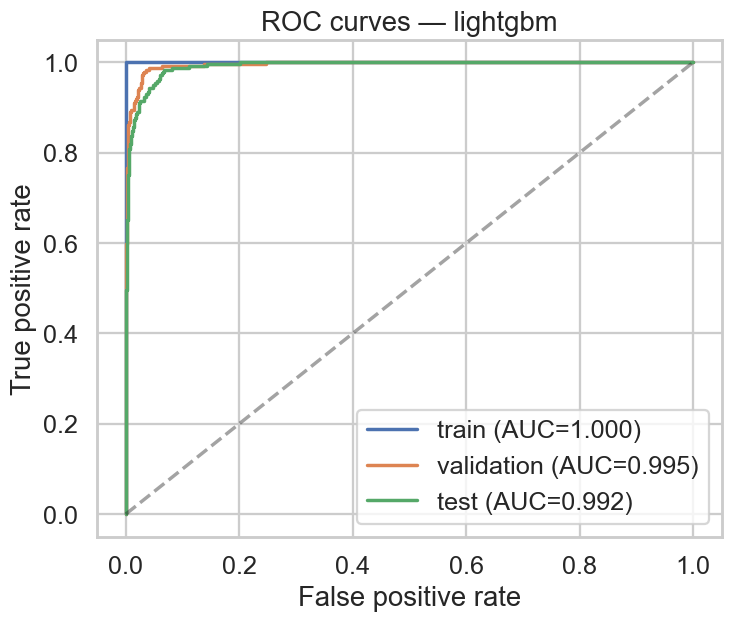

In [15]:
final_metrics = evaluate_model(final_pipeline, splits, threshold=chosen_threshold)
final_metrics["model"] = final_model_name
final_metrics = final_metrics[
    ["model", "split", "roc_auc", "precision", "recall", "f1", "accuracy", "threshold"]
]
final_metrics.to_csv(TABLE_DIR / "modeling_final_metrics.csv", index=False)
display(final_metrics)

artifact = {
    "pipeline": final_pipeline,
    "threshold": chosen_threshold,
    "metadata": {
        "model_name": final_model_name,
        "feature_columns": FEATURE_COLUMNS,
        "numeric_features": NUMERIC_FEATURES,
        "ordinal_features": ORDINAL_FEATURES,
        "nominal_features": NOMINAL_FEATURES,
        "education_order": EDUCATION_ORDER,
        "income_order": INCOME_ORDER,
        "validation_roc_auc": float(val_auc[final_model_name]),
        "test_roc_auc": float(test_auc[final_model_name]),
        "baseline_validation_roc_auc": float(baseline_val_auc),
        "baseline_test_roc_auc": float(baseline_test_auc),
        "random_seed": RANDOM_SEED,
        "split_fractions": {"train": 0.70, "validation": 0.15, "test": 0.15},
        "optuna_trials": N_OPTUNA_TRIALS,
        "target_column": TARGET_COL,
    },
}

model_path = MODEL_DIR / "churn_model_pipeline.joblib"
joblib.dump(artifact, model_path)
print("Saved model:", model_path)

for split_name, (X_split, y_split) in splits.items():
    proba = final_pipeline.predict_proba(X_split)[:, 1]
    pred = (proba >= chosen_threshold).astype(int)
    out = pd.DataFrame(
        {
            "y_true": y_split.values,
            "y_proba_churn": proba,
            "y_pred": pred,
        }
    )
    pred_path = PRED_DIR / f"churn_predictions_{split_name}.csv"
    out.to_csv(pred_path, index=False)
    print("Saved predictions:", pred_path)

# ROC curves (final model)
fig, ax = plt.subplots(figsize=(7, 6))
for split_name, (X_split, y_split) in splits.items():
    proba = final_pipeline.predict_proba(X_split)[:, 1]
    fpr, tpr, _ = roc_curve(y_split, proba)
    auc = roc_auc_score(y_split, proba)
    ax.plot(fpr, tpr, label=f"{split_name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curves — {final_model_name}")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "modeling_final_roc_curves.png", bbox_inches="tight")
plt.show()


## 16. Limitations

- **Cross-sectional snapshot:** no time-to-churn or seasonality.
- **Correlation ≠ causation:** importance ranks association, not retention policy effects.
- **Class imbalance (~16% churn):** metrics emphasize ROC-AUC and recall at the chosen threshold.
- **Unknown categories:** ordinal encoder maps unseen labels to `-1`; monitor drift in production.
- **Test set:** used once after selection; re-running selection on test would invalidate holdout estimates.
